# Logistic Regression



In this notebook, we implement **Logistic Regression** in two ways:

- **From scratch** to understand the core concepts and mathematics  
- **Using Scikit-Learn** to apply a standard machine learning library  

The goal is to compare **theoretical understanding** with **practical implementation**.


In [ ]:
import math
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Implementing Logistic Regression from Scratch

Sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
Loss = -\left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)
$$

In [ ]:

# return probabilty between 1 and 0
def sigmoind(z):
  return 1 / ( 1 + np.exp(-z))



def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Measure the error between y and y_predicted
def loss(y , y_predicted):
  return -(y * np.log(y_predicted) + (1 - y) * np.log(1 - y_predicted))


# Minimize the error
def gradient_descent(X, y, w, b, learning_rate, num_iterations):
    m = X.shape[0]  # Number of training examples
    loss_history = []  # To store the loss for each iteration


    for i in range(num_iterations):
        # 1. Forward Propagation (Calculate prediction y_predicted or A)
        z = np.dot(X, w) + b
        y_predicted = sigmoind(z)

        # 2. Backward Propagation (Calculate gradients)
        # dZ is the gradient of Loss wrt Z, which simplifies to:
        dZ = y_predicted - y



        #Compute loss
        loss_history.append(np.mean(loss(y, y_predicted)))


        # Calculate gradients for weights (dW) and bias (dB)
        dW = (1 / m) * np.dot(X.T, dZ)
        dB = (1 / m) * np.sum(dZ)

        # 3. Update Parameters
        w = w - learning_rate * dW
        b = b - learning_rate * dB




        # Optional: Calculate and store loss for monitoring

    return w, b , loss_history


In [ ]:
def categorical_crossentropy_loss(y_true, y_predicted):
    """
    Calculates the categorical cross-entropy loss for multi-class classification.

    Args:
        y_true (np.array): True labels, expected to be one-hot encoded.
        y_predicted (np.array): Predicted probabilities, usually from a softmax activation.

    Returns:
        float: The average categorical cross-entropy loss.
    """
    # Clip predictions to avoid log(0) and log(1) issues, ensuring numerical stability
    y_predicted = np.clip(y_predicted, 1e-10, 1 - 1e-10)
    # Calculate cross-entropy loss for each sample and sum across classes
    # Then take the mean across samples
    return -np.mean(np.sum(y_true * np.log(y_predicted), axis=1))


The `categorical_crossentropy_loss` function above is suitable for multi-class classification.

Key differences and considerations for multi-class logistic regression (often called Softmax Regression):

1.  **Activation Function**: Instead of `sigmoid`, you would typically use the `softmax` function (which is already defined in your notebook) as the output layer's activation function to get probabilities for each class.
2.  **True Labels (y_true)**: Your true labels (`y`) should be converted to a **one-hot encoded** format. For example, if you have 3 classes and a sample belongs to class 1, its one-hot encoding would be `[0, 1, 0]`.
3.  **Predicted Probabilities (y_predicted)**: These would be the output of your `softmax` function, providing a probability distribution over all classes for each sample.
4.  **Gradient Descent**: The `gradient_descent` function would need significant modifications to handle multi-class predictions, one-hot encoded labels, and the derivatives of the softmax and categorical cross-entropy functions.

* Custom dataset

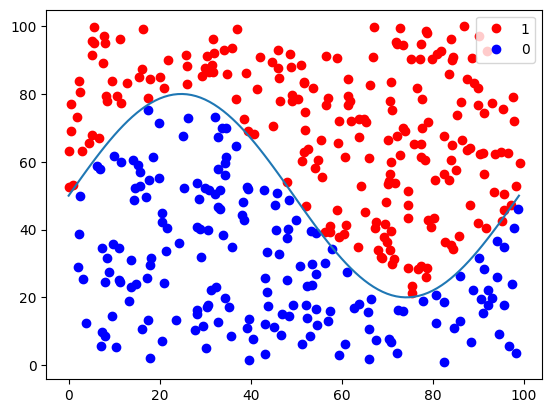

In [ ]:
# Let's build a custom dataset for our logistic regression model

n_points = 400  # num of points in generated data
max_coordinate_value = 100  # max possible value taken by the x or y coordinate of a point

points = np.random.rand(n_points, 2) * max_coordinate_value

l = np.sin(2*math.pi*(points[:, 0]/max_coordinate_value))
l = (l*0.3*max_coordinate_value)+(max_coordinate_value/2)
mask = points[:, 1] > l

labels = np.zeros(n_points)
labels[mask] = 1

divider = (30 * np.sin(2*math.pi*np.linspace(0, max_coordinate_value, max_coordinate_value)/max_coordinate_value))
divider = max_coordinate_value/2 + divider

plt.plot(points[mask][:, 0], points[mask][:, 1], 'ro', label='1')
plt.plot(points[~mask][:, 0], points[~mask][:, 1], 'bo', label='0')
plt.plot(divider)  # visualization only

plt.legend()
plt.show()

In [ ]:
# rename to X and y.

X = points
y = labels
print(f'Current X shape: {X.shape}')
print(f'Current y shape: {y.shape}')




# we will add 1 as bias
bias = np.ones((X.shape[0], 1))
X = np.concatenate((bias, X), axis=1)

print(f'Current X shape: {X.shape}')
print(f'Current y shape: {y.shape}')

Current X shape: (400, 2)
Current y shape: (400,)
Current X shape: (400, 3)
Current y shape: (400,)


Theate = [w , b]

In [ ]:
num_iters = 40000
lr = 1e-3 # Learning rate




w ,b ,  loss_history = gradient_descent(X, y, np.zeros(X.shape[1]), 0, lr, num_iters)









In [ ]:

y_predicted = sigmoind(np.dot(X, w) + b)
y_predicted = np.round(y_predicted) # if 0.7 it will make it 1




correct_pred = np.sum(y_predicted == y)
total_count = len(y)
accuracy = correct_pred / total_count


print(f'The model predicted {correct_pred} out of {total_count} predictions correctly')
print(f'Accuracy: {accuracy}')

The model predicted 344 out of 400 predictions correctly
Accuracy: 0.86


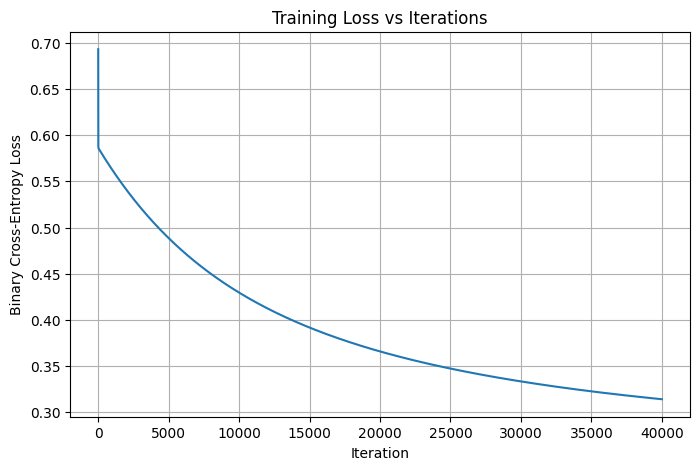

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss vs Iterations")
plt.grid(True)
plt.show()


# --------------

# Sklearn implementation

In [ ]:
# let's load iris and have a look at it
iris_data = load_iris()  # returns a dict
print(iris_data.keys(), '\n')




print('given features:', iris_data['feature_names'])
print('flower names (class names):', iris_data['target_names'])




dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) 

given features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
flower names (class names): ['setosa' 'versicolor' 'virginica']


In [ ]:
x = iris_data['data']
y = iris_data['target']

print(x.shape, y.shape)


(150, 4) (150,)


In [ ]:
#spilt data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    x, y, # Use the iris dataset variables x and y
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # for reproducibility
    shuffle=True         # shuffle before splitting
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

correct_pred = np.sum(y_pred == y_test)
total_count = len(y_test)
accuracy = correct_pred / total_count

print(f'The model predicted {correct_pred} out of {total_count} predictions correctly')
print(f'Accuracy: {accuracy}')

The model predicted 30 out of 30 predictions correctly
Accuracy: 1.0
